In [36]:
#Import models and libraries
from DT.DecisionTree import DecisionTree
from sklearn.tree import DecisionTreeClassifier
from GNB.gaussian_naive_bayes import GNB
from LogisticRegresssion.LogisticRegression import MultiLogReg
from tensorflow import keras
from SVM.linear_svm import LinearSVMScartch
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report , f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from Kfolds import run_kfold
import itertools
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
from diagnosis_curves import analysis_curves
import matplotlib.pyplot as plt




In [16]:
#Download Data
(X_train, y_train_O), (X_test, y_test) = keras.datasets.mnist.load_data()


In [17]:
# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

In [18]:
import numpy as np
from skimage.feature import hog

def extract_hog_features(X):
    features = []

    for img in X:
        img_2d = img.reshape(28, 28)

        hog_features = hog(
            img_2d,
            orientations=9,
            pixels_per_cell=(4, 4),
            cells_per_block=(2, 2),
            block_norm='L2-Hys',
            feature_vector=True
        )

        features.append(hog_features)

    return np.array(features)

In [19]:
X_train_HOG = extract_hog_features(X_train)
X_test_HOG = extract_hog_features(X_test)

In [20]:
pca = PCA(n_components=50)  

X_train_hog_pca = pca.fit_transform(X_train_HOG)
X_test_hog_pca = pca.transform(X_test_HOG)

In [8]:
print(X_test_hog_pca.shape)

(10000, 50)


In [29]:
vgg_train = np.load("vgg16_gap_train.npz")
vgg_test  = np.load("vgg16_gap_test.npz")

X_train_vgg, y_train = vgg_train["X"], vgg_train["y"]
X_test_vgg, y_test   = vgg_test["X"], vgg_test["y"]

In [34]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_hog_pca, y_train_O,
    test_size=0.2,
    stratify=y_train_O,
    random_state=42
)

In [22]:
print(X_train.shape, X_val.shape, y_train.shape, y_val.shape)

(48000, 50) (12000, 50) (48000,) (12000,)


In [23]:


def manual_grid_search_DT(X, y, param_grid, k=3):

    keys = list(param_grid.keys())
    values = list(param_grid.values())

    best_score = -1
    best_params = None
    results = []

    for combo in itertools.product(*values):

        params = dict(zip(keys, combo))

        print("\nTesting:", params)

        kf = KFold(n_splits=k, shuffle=True, random_state=42)

        fold_scores = []

        for train_idx, val_idx in kf.split(X):

            X_train_fold = X[train_idx]
            X_val_fold = X[val_idx]

            y_train_fold = y[train_idx]
            y_val_fold = y[val_idx]

            model = DecisionTree(
                maxDepth=params["maxDepth"],
                minSamplesSplit=params["minSamplesSplit"],
                minSampleLeafs=params["minSampleLeafs"],
                criterion=params["criterion"],
                maxFeatures=params["maxFeatures"]
            )

            model.fit(X_train_fold, y_train_fold)

            preds = model.predict(X_val_fold)

            score = f1_score(y_val_fold, preds, average="macro")

            fold_scores.append(score)

        avg_score = sum(fold_scores) / len(fold_scores)

        print("Average score:", avg_score)

        results.append((params, avg_score))

        if avg_score > best_score:
            best_score = avg_score
            best_params = params

    print("\nBest params:", best_params)
    print("Best score:", best_score)

    return best_params, best_score, results

In [25]:
#DT hyper parameter tuning + Validation
param_grid = {
    "maxDepth": [12, 15],
    "minSamplesSplit": [5, 20],
    "minSampleLeafs": [5, 20],
    "criterion": ["gini"],
    "maxFeatures": ["sqrt"]
}
best_params, _, _ = manual_grid_search_DT(X_train_HOG , y_train_O , param_grid)




Testing: {'maxDepth': 12, 'minSamplesSplit': 5, 'minSampleLeafs': 5, 'criterion': 'gini', 'maxFeatures': 'sqrt'}
Average score: 0.7950246111439748

Testing: {'maxDepth': 12, 'minSamplesSplit': 5, 'minSampleLeafs': 20, 'criterion': 'gini', 'maxFeatures': 'sqrt'}
Average score: 0.7926895761140674

Testing: {'maxDepth': 12, 'minSamplesSplit': 20, 'minSampleLeafs': 5, 'criterion': 'gini', 'maxFeatures': 'sqrt'}
Average score: 0.799396424419307

Testing: {'maxDepth': 12, 'minSamplesSplit': 20, 'minSampleLeafs': 20, 'criterion': 'gini', 'maxFeatures': 'sqrt'}
Average score: 0.7973744955550516

Testing: {'maxDepth': 15, 'minSamplesSplit': 5, 'minSampleLeafs': 5, 'criterion': 'gini', 'maxFeatures': 'sqrt'}
Average score: 0.8198144970051658

Testing: {'maxDepth': 15, 'minSamplesSplit': 5, 'minSampleLeafs': 20, 'criterion': 'gini', 'maxFeatures': 'sqrt'}
Average score: 0.7984652723605574

Testing: {'maxDepth': 15, 'minSamplesSplit': 20, 'minSampleLeafs': 5, 'criterion': 'gini', 'maxFeatures': '

In [27]:
#Decision tree
#Best params from Grid search =>{'maxDepth': 15, 'minSamplesSplit': 20, 'minSampleLeafs': 5, 'criterion': 'gini', 'maxFeatures': 'sqrt'}

dt = DecisionTree(**best_params)

dt.fit(X_train_HOG , y_train_O)
predictions = dt.predict(X_test_HOG)
print(classification_report(
    y_test, predictions,
))



              precision    recall  f1-score   support

           0       0.85      0.90      0.87       980
           1       0.96      0.94      0.95      1135
           2       0.84      0.84      0.84      1032
           3       0.79      0.80      0.79      1010
           4       0.83      0.84      0.84       982
           5       0.84      0.81      0.82       892
           6       0.91      0.87      0.89       958
           7       0.83      0.84      0.84      1028
           8       0.78      0.76      0.77       974
           9       0.81      0.83      0.82      1009

    accuracy                           0.85     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.85      0.85      0.85     10000



In [30]:
#Decision Tree CNN results
dt = DecisionTree(**best_params)

dt.fit(X_train_vgg , y_train_O)
predictions = dt.predict(X_test_vgg)
print(classification_report(
    y_test, predictions,
))



              precision    recall  f1-score   support

           0       0.84      0.86      0.85       980
           1       0.95      0.95      0.95      1135
           2       0.63      0.63      0.63      1032
           3       0.69      0.76      0.73      1010
           4       0.80      0.78      0.79       982
           5       0.63      0.63      0.63       892
           6       0.75      0.74      0.74       958
           7       0.78      0.78      0.78      1028
           8       0.80      0.77      0.79       974
           9       0.80      0.75      0.77      1009

    accuracy                           0.77     10000
   macro avg       0.77      0.77      0.77     10000
weighted avg       0.77      0.77      0.77     10000



Starting Decision Tree Learning Curve evaluations...

--- Running Evaluation 1/2: ACCURACY ---
Size 20/60000 -> Train: 0.4000 | Val: 0.1746
Size 8588/60000 -> Train: 0.8775 | Val: 0.7679
Size 17157/60000 -> Train: 0.8903 | Val: 0.8048
Size 25725/60000 -> Train: 0.8953 | Val: 0.8098
Size 34294/60000 -> Train: 0.9034 | Val: 0.8218
Size 42862/60000 -> Train: 0.9046 | Val: 0.8230
Size 51431/60000 -> Train: 0.9096 | Val: 0.8410
Size 60000/60000 -> Train: 0.9137 | Val: 0.8491


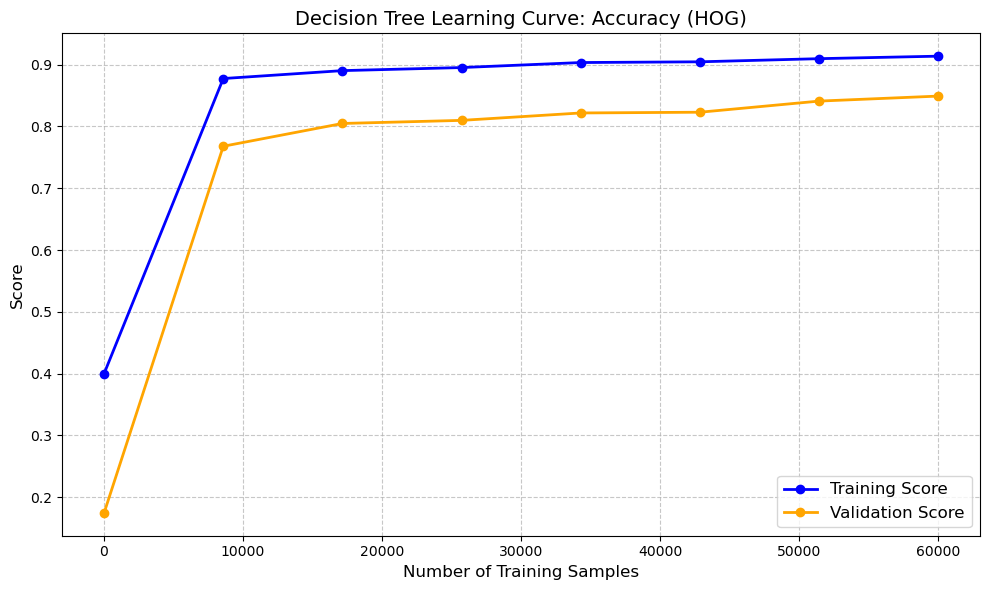


--- Running Evaluation 2/2: MACRO F1-SCORE ---
Size 20/60000 -> Train: 0.1548 | Val: 0.0532
Size 8588/60000 -> Train: 0.8763 | Val: 0.7666
Size 17157/60000 -> Train: 0.8836 | Val: 0.7862
Size 25725/60000 -> Train: 0.8973 | Val: 0.8195
Size 34294/60000 -> Train: 0.9051 | Val: 0.8173
Size 42862/60000 -> Train: 0.9064 | Val: 0.8308
Size 51431/60000 -> Train: 0.9084 | Val: 0.8344
Size 60000/60000 -> Train: 0.9130 | Val: 0.8474


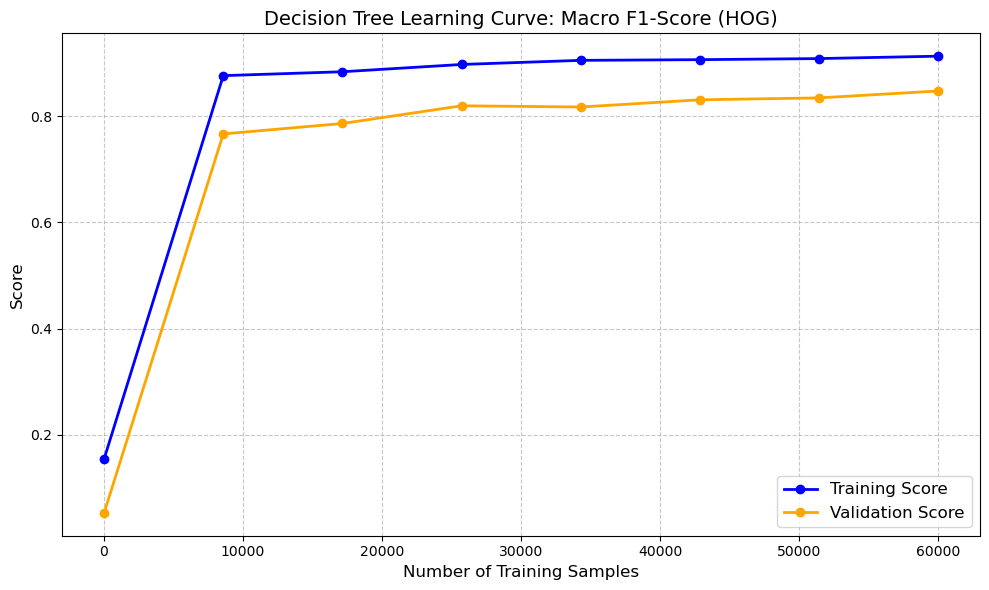

In [31]:
#Decision Tree overfitting underfitting analysis
print("Starting Decision Tree Learning Curve evaluations...\n")

def train_dt_hog(X_subset, y_subset):
    model = DecisionTree(
        maxDepth=15,
        minSamplesSplit=20,
        minSampleLeafs=1,
        criterion="entropy",
        maxFeatures="sqrt",
        randomState=42
    )
    model.fit(X_subset, y_subset)
    return model

def predict_dt_hog(model, X):
    return model.predict(X)

def metric_acc(y_true, y_pred):
    return accuracy_score(y_true, y_pred)

def metric_f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro")


print("--- Running Evaluation 1/2: ACCURACY ---")
subset_sizes_acc, train_trends_acc, val_trends_acc = analysis_curves(
    X_train=X_train_HOG,
    y_train=y_train_O,
    X_val=X_test_HOG,
    y_val=y_test,
    train_fn=train_dt_hog,
    predict_fn=predict_dt_hog,
    metric_fn=metric_acc,
    num_steps=8,
    title="Decision Tree Learning Curve: Accuracy (HOG)"
)


print("\n--- Running Evaluation 2/2: MACRO F1-SCORE ---")
subset_sizes_f1, train_trends_f1, val_trends_f1 = analysis_curves(
    X_train=X_train_HOG,
    y_train=y_train_O,
    X_val=X_test_HOG,
    y_val=y_test,
    train_fn=train_dt_hog,
    predict_fn=predict_dt_hog,
    metric_fn=metric_f1_macro,
    num_steps=8,
    title="Decision Tree Learning Curve: Macro F1-Score (HOG)"
)



HOG + PCA

=== K-FOLD VALIDATION ===
Fold 1 → F1: 0.9277
Fold 2 → F1: 0.9309
Fold 3 → F1: 0.9298
Fold 4 → F1: 0.9330
Fold 5 → F1: 0.9354

K-Fold Avg F1: 0.9313638348117264

=== TEST RESULTS ===
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       980
           1       0.99      0.96      0.97      1135
           2       0.93      0.95      0.94      1032
           3       0.93      0.94      0.94      1010
           4       0.95      0.95      0.95       982
           5       0.95      0.92      0.94       892
           6       0.97      0.94      0.96       958
           7       0.96      0.89      0.92      1028
           8       0.86      0.93      0.89       974
           9       0.90      0.92      0.91      1009

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



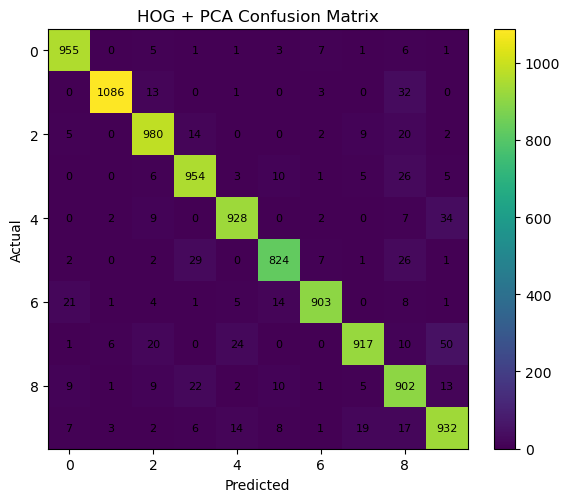


VGG (RAW)

=== K-FOLD VALIDATION ===
Fold 1 → F1: 0.8613
Fold 2 → F1: 0.8681
Fold 3 → F1: 0.8643
Fold 4 → F1: 0.8580
Fold 5 → F1: 0.8606

K-Fold Avg F1: 0.862471802050865

=== TEST RESULTS ===
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       980
           1       0.99      0.94      0.97      1135
           2       0.81      0.64      0.71      1032
           3       0.76      0.90      0.82      1010
           4       0.90      0.92      0.91       982
           5       0.71      0.73      0.72       892
           6       0.93      0.86      0.89       958
           7       0.86      0.89      0.87      1028
           8       0.88      0.94      0.91       974
           9       0.90      0.90      0.90      1009

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



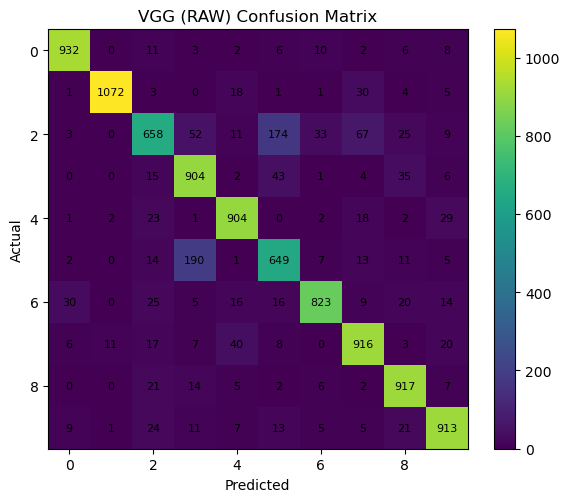


VGG + PCA (50)

=== K-FOLD VALIDATION ===
Fold 1 → F1: 0.8729
Fold 2 → F1: 0.8718
Fold 3 → F1: 0.8690
Fold 4 → F1: 0.8673
Fold 5 → F1: 0.8687

K-Fold Avg F1: 0.8699495597204253

=== TEST RESULTS ===
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       980
           1       0.95      0.93      0.94      1135
           2       0.82      0.74      0.78      1032
           3       0.86      0.88      0.87      1010
           4       0.93      0.94      0.93       982
           5       0.80      0.82      0.81       892
           6       0.94      0.88      0.91       958
           7       0.82      0.84      0.83      1028
           8       0.81      0.90      0.85       974
           9       0.92      0.89      0.91      1009

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



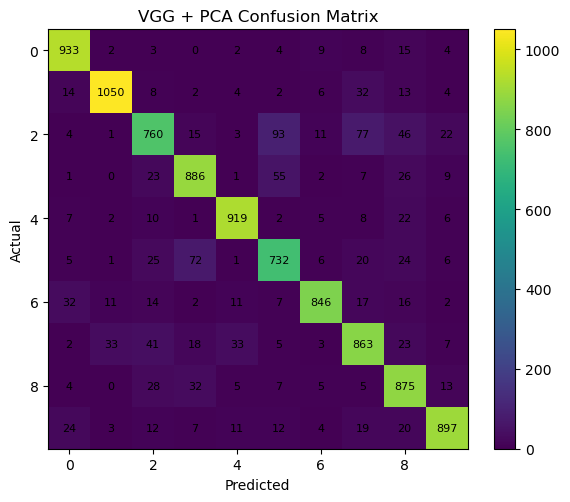

Size 20/60000 -> Train: 1.0000 | Val: 0.1585
Size 8588/60000 -> Train: 0.9332 | Val: 0.9350
Size 17157/60000 -> Train: 0.9320 | Val: 0.9371
Size 25725/60000 -> Train: 0.9312 | Val: 0.9374
Size 34294/60000 -> Train: 0.9315 | Val: 0.9382
Size 42862/60000 -> Train: 0.9315 | Val: 0.9379
Size 51431/60000 -> Train: 0.9317 | Val: 0.9376
Size 60000/60000 -> Train: 0.9316 | Val: 0.9380


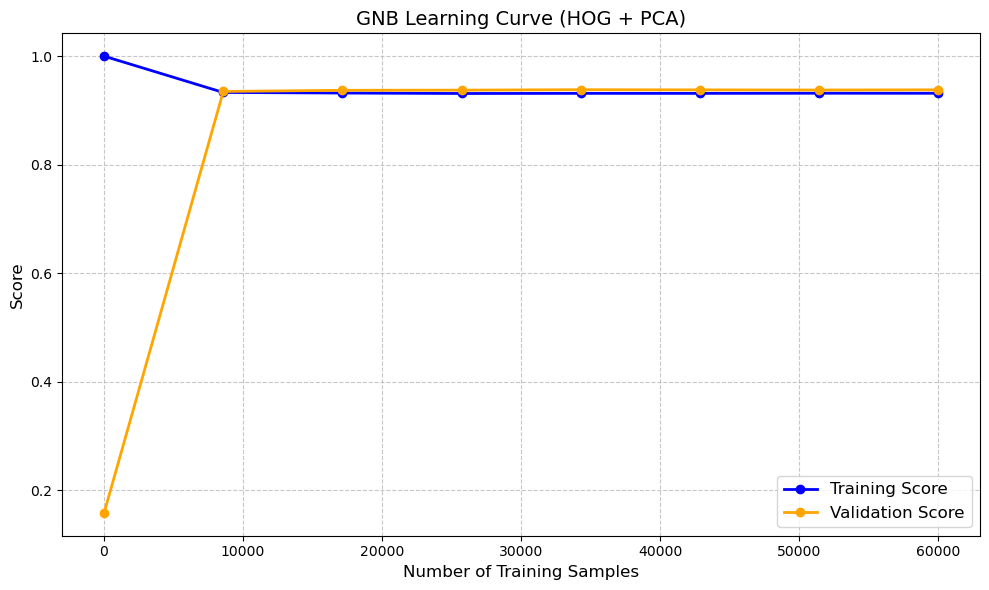

Size 20/60000 -> Train: 1.0000 | Val: 0.0975
Size 8588/60000 -> Train: 0.9373 | Val: 0.9370
Size 17157/60000 -> Train: 0.9330 | Val: 0.9376
Size 25725/60000 -> Train: 0.9320 | Val: 0.9370
Size 34294/60000 -> Train: 0.9313 | Val: 0.9369
Size 42862/60000 -> Train: 0.9313 | Val: 0.9372
Size 51431/60000 -> Train: 0.9310 | Val: 0.9371
Size 60000/60000 -> Train: 0.9315 | Val: 0.9379


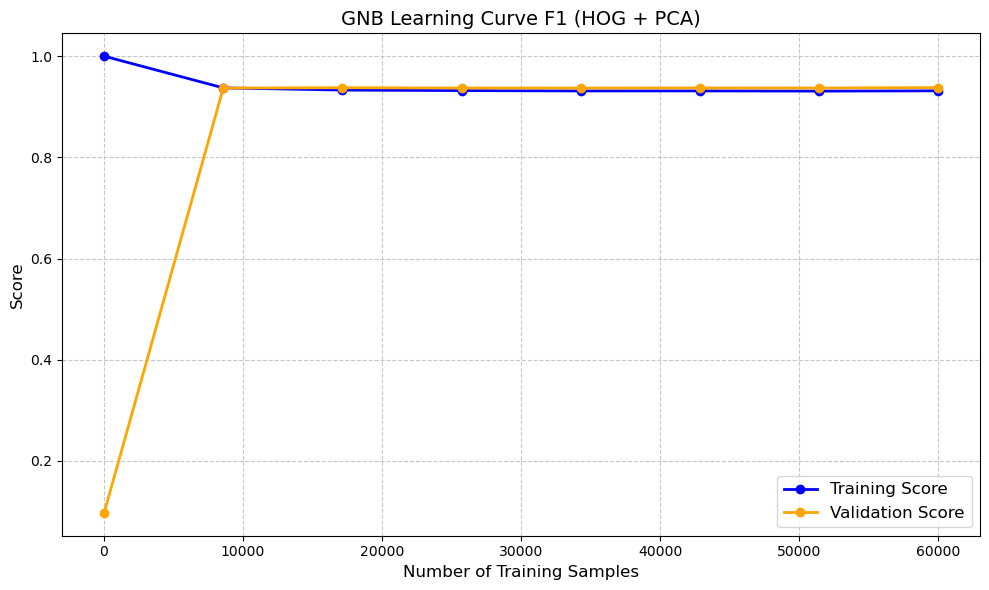

(array([   20,  8588, 17157, 25725, 34294, 42862, 51431, 60000]),
 [1.0,
  0.9373315975862564,
  0.9329825219578278,
  0.931981676257311,
  0.9312650617846924,
  0.9313403997979446,
  0.9309533760802664,
  0.9315123137923974],
 [0.09746238225087064,
  0.9370446802657174,
  0.9376014884687054,
  0.9370364883999758,
  0.936935861406168,
  0.9371748126496191,
  0.9370829383838288,
  0.9378892050417699])

In [37]:

# ======================
# Helper Functions
# ======================
def train_gnb(X, y):
    gnb = GNB()
    gnb.gaussian_naive_train(X, y)
    return gnb

def predict_gnb(model, X):
    return model.predict(X)

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.colorbar()

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=8)

    plt.tight_layout()
    plt.show()


# ======================
# HOG + PCA (YOUR ORIGINAL)
# ======================
print("\n==============================")
print("HOG + PCA")
print("==============================")

print("\n=== K-FOLD VALIDATION ===")
run_kfold(X_train, y_train, train_gnb, predict_gnb, k=5, binary=0)

gnb = GNB()
gnb.gaussian_naive_train(X_train, y_train)

predictions_hog = gnb.predict(X_test_hog_pca)

print("\n=== TEST RESULTS ===")
print(classification_report(y_test, predictions_hog))

plot_cm(y_test, predictions_hog, "HOG + PCA Confusion Matrix")


# ======================
# LOAD VGG FEATURES
# ======================
vgg_train = np.load("vgg16_gap_train.npz")
vgg_test  = np.load("vgg16_gap_test.npz")

X_train_vgg, y_train = vgg_train["X"], vgg_train["y"]
X_test_vgg, y_test   = vgg_test["X"], vgg_test["y"]


# ======================
# VGG (RAW)
# ======================
print("\n==============================")
print("VGG (RAW)")
print("==============================")

print("\n=== K-FOLD VALIDATION ===")
run_kfold(X_train_vgg, y_train, train_gnb, predict_gnb, k=5, binary=0)

gnb = GNB()
gnb.gaussian_naive_train(X_train_vgg, y_train)

predictions_vgg = gnb.predict(X_test_vgg)

print("\n=== TEST RESULTS ===")
print(classification_report(y_test, predictions_vgg))

plot_cm(y_test, predictions_vgg, "VGG (RAW) Confusion Matrix")


# ======================
# VGG + PCA (50)
# ======================
print("\n==============================")
print("VGG + PCA (50)")
print("==============================")

pca = PCA(n_components=50)

X_train_vgg_pca = pca.fit_transform(X_train_vgg)
X_test_vgg_pca = pca.transform(X_test_vgg)

print("\n=== K-FOLD VALIDATION ===")
run_kfold(X_train_vgg_pca, y_train, train_gnb, predict_gnb, k=5, binary=0)

gnb = GNB()
gnb.gaussian_naive_train(X_train_vgg_pca, y_train)

predictions_vgg_pca = gnb.predict(X_test_vgg_pca)

print("\n=== TEST RESULTS ===")
print(classification_report(y_test, predictions_vgg_pca))

plot_cm(y_test, predictions_vgg_pca, "VGG + PCA Confusion Matrix")
from sklearn.metrics import accuracy_score

# metric
def metric_fn(y_true, y_pred):
    return accuracy_score(y_true, y_pred)
def metric_f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average='macro')

# run analysis
analysis_curves(
    X_train_hog_pca,
    y_train,
    X_test_hog_pca,   # using test as validation
    y_test,
    train_fn=train_gnb,
    predict_fn=predict_gnb,
    metric_fn=metric_fn,
    num_steps=8,
    title="GNB Learning Curve (HOG + PCA)"
)
analysis_curves(
    X_train_hog_pca,
    y_train,
    X_test_hog_pca,   # using test as validation
    y_test,
    train_fn=train_gnb,
    predict_fn=predict_gnb,
    metric_fn=metric_f1_macro,
    num_steps=8,
    title="GNB Learning Curve F1 (HOG + PCA)"
)

Starting Learning Curve evaluations...

--- Running Evaluation 1/2: ACCURACY ---
Size 20/48000 -> Train: 1.0000 | Val: 0.5843
Size 6874/48000 -> Train: 0.9041 | Val: 0.9009
Size 13728/48000 -> Train: 0.9053 | Val: 0.9028
Size 20582/48000 -> Train: 0.9064 | Val: 0.9032
Size 27437/48000 -> Train: 0.9058 | Val: 0.9018
Size 34291/48000 -> Train: 0.9069 | Val: 0.9038
Size 41145/48000 -> Train: 0.9074 | Val: 0.9054
Size 48000/48000 -> Train: 0.9079 | Val: 0.9048


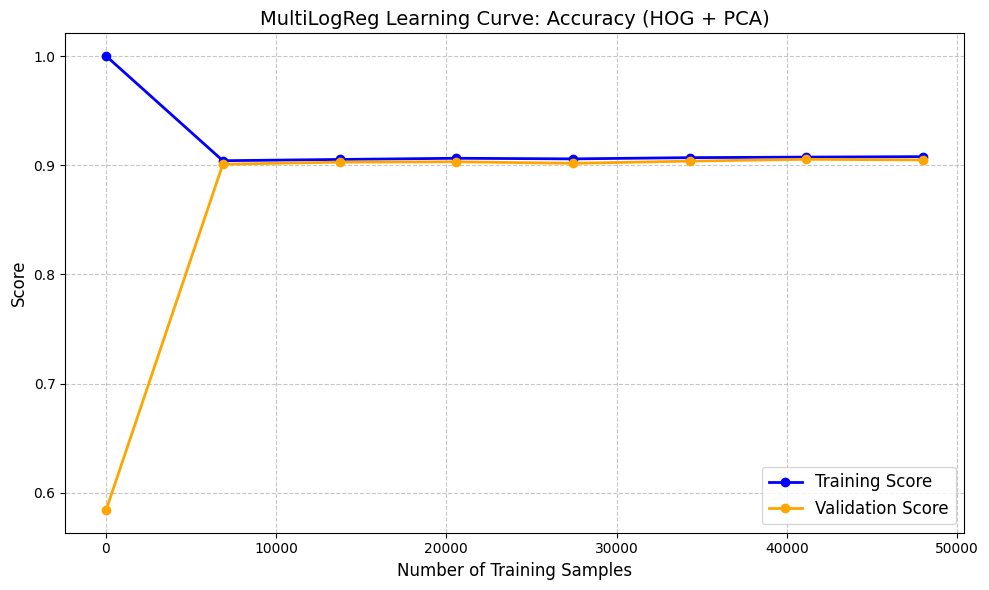


--- Running Evaluation 2/2: MACRO F1-SCORE ---
Size 20/48000 -> Train: 1.0000 | Val: 0.5121
Size 6874/48000 -> Train: 0.9031 | Val: 0.9004
Size 13728/48000 -> Train: 0.9044 | Val: 0.9024
Size 20582/48000 -> Train: 0.9057 | Val: 0.9028
Size 27437/48000 -> Train: 0.9052 | Val: 0.9013
Size 34291/48000 -> Train: 0.9065 | Val: 0.9034
Size 41145/48000 -> Train: 0.9070 | Val: 0.9050
Size 48000/48000 -> Train: 0.9073 | Val: 0.9045


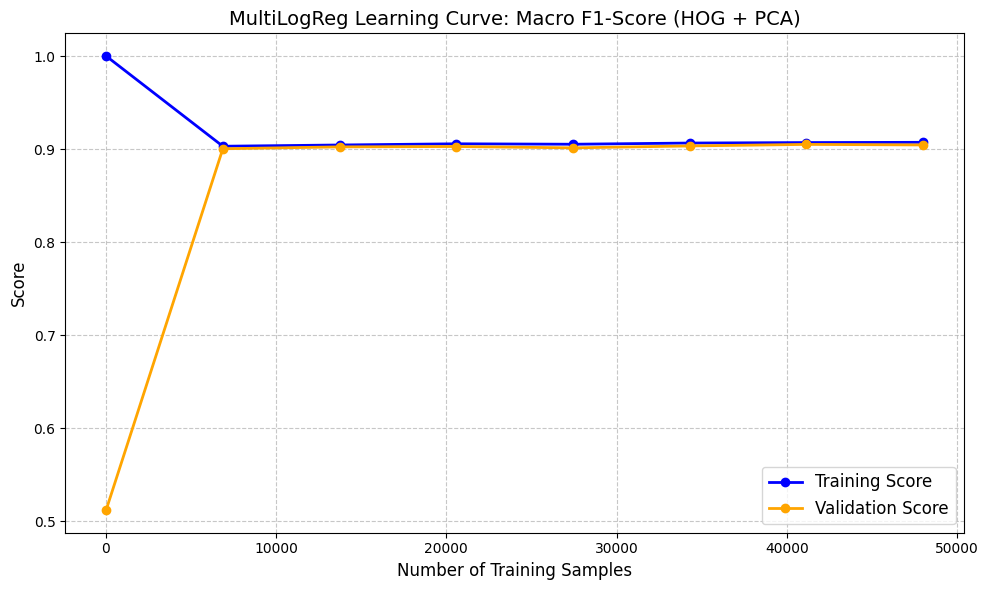

In [13]:
from sklearn.metrics import f1_score, accuracy_score

print("Starting Learning Curve evaluations...\n")
def train_multilogreg(X_subset, y_subset):
    model = MultiLogReg(
        max_iterations=100, 
        learning_rate=0.1, 
        reg_eqn='L2',       
        reg_param=0.1,      
        random_state=42
    )
    model.fit(X_subset, y_subset)
    return model

def predict_multilogreg(model, X):
    return model.predict(X)

def metric_acc(y_true, y_pred):
    return accuracy_score(y_true, y_pred)

def metric_f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average='macro')


print("--- Running Evaluation 1/2: ACCURACY ---")
subset_sizes_acc, train_trends_acc, val_trends_acc = analysis_curves(
    X_train=X_train, 
    y_train=y_train, 
    X_val=X_val, 
    y_val=y_val, 
    train_fn=train_multilogreg, 
    predict_fn=predict_multilogreg, 
    metric_fn=metric_acc, 
    num_steps=8,
    title="MultiLogReg Learning Curve: Accuracy (HOG + PCA)"
)


print("\n--- Running Evaluation 2/2: MACRO F1-SCORE ---")
subset_sizes_f1, train_trends_f1, val_trends_f1 = analysis_curves(
    X_train=X_train, 
    y_train=y_train, 
    X_val=X_val, 
    y_val=y_val, 
    train_fn=train_multilogreg, 
    predict_fn=predict_multilogreg, 
    metric_fn=metric_f1_macro, 
    num_steps=8,
    title="MultiLogReg Learning Curve: Macro F1-Score (HOG + PCA)"
)

In [8]:
import itertools
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
from sklearn.decomposition import PCA
from GridSearches import gridSearchLog


# 1. Comprehensive Hyperparameter Grid
# Covers iterations up to 1000 and includes L1/L2 regularization as requested
param_grid = {
    'max_iterations': [100, 500, 1000, 1500],       # Checks for deep convergence
    'learning_rate': [0.001, 0.01, 0.1, 0.5], # Adds a safety low-rate
    'class_weight': [None, 'balanced'],
    'reg_eqn': [None, 'L1', 'L2'],
    'reg_param': [0.001, 0.01, 0.1, 1.0, 10.0], # Wider range of penalties
    'random_state': [42]
}

# 2. Define the 4 Preprocessing Configurations using your provided variables
# We flatten the raw X_train for the model
X_train_raw = X_train.reshape(X_train.shape[0], -1)

# Generate PCA Only (50) for the full raw dataset
pca_raw = PCA(n_components=50, random_state=42)
X_train_pca_only = pca_raw.fit_transform(X_train_raw)

configs = {
    "Raw Pixels": X_train_raw,
    "PCA Only (50)": X_train_pca_only,
    "HOG Only": X_train_HOG,        
    "HOG + PCA (50)": X_train_hog_pca # Using your HOG+PCA variable
}

# 3. Execution Loop
final_comparison = {}

for name, data in configs.items():
    print(f"\n" + "="*60)
    print(f"STARTING FULL DATA GRID SEARCH: {name}")
    print(f"Feature Dimensions: {data.shape[1]}")
    print("="*60)
    
    # Calls your custom gridSearchLog function on the full y_train (60,000 samples)
    best_params, best_score, _ = gridSearchLog(
        x=data, 
        y=y_train, 
        param_grid=param_grid, 
        k_cross=3
    )
    
    final_comparison[name] = {
        "best_score": best_score,
        "best_params": best_params
    }

# 4. Final Performance Report
print("\n" + "#"*60)
print("FINAL PREPROCESSING PERFORMANCE SUMMARY (PHASE 2)")
print("#"*60)
for name, results in final_comparison.items():
    print(f"{name:15} | Best Macro F1: {results['best_score']:.4f}")
    print(f"Optimal Params: {results['best_params']}")
    print("-" * 30)


STARTING FULL DATA GRID SEARCH: Raw Pixels
Feature Dimensions: 784
Average f1-score of {'max_iterations': 100, 'learning_rate': 0.001, 'class_weight': None, 'reg_eqn': None, 'reg_param': 0.001, 'random_state': 42}: 0.23209568599337702
Average f1-score of {'max_iterations': 100, 'learning_rate': 0.001, 'class_weight': None, 'reg_eqn': None, 'reg_param': 0.01, 'random_state': 42}: 0.23209568599337702
Average f1-score of {'max_iterations': 100, 'learning_rate': 0.001, 'class_weight': None, 'reg_eqn': None, 'reg_param': 0.1, 'random_state': 42}: 0.23209568599337702
Average f1-score of {'max_iterations': 100, 'learning_rate': 0.001, 'class_weight': None, 'reg_eqn': None, 'reg_param': 1.0, 'random_state': 42}: 0.23209568599337702
Average f1-score of {'max_iterations': 100, 'learning_rate': 0.001, 'class_weight': None, 'reg_eqn': None, 'reg_param': 10.0, 'random_state': 42}: 0.23209568599337702
Average f1-score of {'max_iterations': 100, 'learning_rate': 0.001, 'class_weight': None, 'reg_eqn

KeyboardInterrupt: 

In [2]:
#Import models and libraries
from DT.DecisionTree import DecisionTree
from sklearn.tree import DecisionTreeClassifier
#from GNB.gaussian_naive_bayes import GNB
#from LogisticRegresssion.LogisticRegression import MultiLogReg
from tensorflow import keras
from SVM.linear_svm import LinearSVMScartch
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report , f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from Kfolds import run_kfold
import itertools
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
from diagnosis_curves import analysis_curves



In [6]:
X_train.shape

(60000, 28, 28)

In [8]:

# ============================================================
# MultiClass SVM — Setup: imports, grid search, all 3 splits
# ============================================================
from SVM.multiclass_svm import MultiClassSVMScratch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

RANDOM_STATE = 42

# Reload original y_train (60000) in case it was overwritten by earlier split cells
(_, y_train_orig), (_, _) = keras.datasets.mnist.load_data()

def manual_grid_search_SVM(X_tr, y_tr, X_v, y_v, label=''):
    C_values  = [0.1, 1.0, 10.0]
    lr_values = [0.001, 0.0005, 0.0001]
    print(f"{'C':>6}  {'LR':>8}  {'Val Acc':>9}")
    print("-" * 30)
    results = []
    for C in C_values:
        for lr in lr_values:
            model = MultiClassSVMScratch(C=C, learning_rate=lr,
                                         n_epochs=30, random_state=RANDOM_STATE)
            model.fit(X_tr, y_tr)
            acc = accuracy_score(y_v, model.predict(X_v))
            results.append((C, lr, acc))
            print(f"{C:>6}  {lr:>8}  {acc:>9.4f}")
    best = max(results, key=lambda x: x[2])
    print(f"\nBest: C={best[0]}, lr={best[1]}, Val Acc={best[2]:.4f}")
    return best[0], best[1]

# ---------- Split 1: HOG only ----------
scaler_hog = StandardScaler()
X_hog_s      = scaler_hog.fit_transform(X_train_HOG)
X_test_hog_s = scaler_hog.transform(X_test_HOG)

X_tr_hog, X_v_hog, y_tr_hog, y_v_hog = train_test_split(
    X_hog_s, y_train_orig, test_size=0.2, stratify=y_train_orig, random_state=RANDOM_STATE)

# ---------- Split 2: PCA only (raw pixels) ----------
X_flat      = X_train.reshape(X_train.shape[0], -1)   # (60000, 784)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

scaler_raw   = StandardScaler()
X_flat_s     = scaler_raw.fit_transform(X_flat)
X_test_flat_s = scaler_raw.transform(X_test_flat)

pca_only      = PCA(n_components=50, random_state=RANDOM_STATE)
X_pca         = pca_only.fit_transform(X_flat_s)
X_test_pca    = pca_only.transform(X_test_flat_s)

X_tr_pca, X_v_pca, y_tr_pca, y_v_pca = train_test_split(
    X_pca, y_train_orig, test_size=0.2, stratify=y_train_orig, random_state=RANDOM_STATE)

# ---------- Split 3: HOG + PCA ----------
pca_hog       = PCA(n_components=50, random_state=RANDOM_STATE)
X_hog_pca     = pca_hog.fit_transform(X_hog_s)
X_test_hog_pca_svm = pca_hog.transform(X_test_hog_s)

X_tr_hog_pca, X_v_hog_pca, y_tr_hog_pca, y_v_hog_pca = train_test_split(
    X_hog_pca, y_train_orig, test_size=0.2, stratify=y_train_orig, random_state=RANDOM_STATE)

print(f"HOG only  — Train: {X_tr_hog.shape},     Test: {X_test_hog_s.shape}")
print(f"PCA only  — Train: {X_tr_pca.shape},      Test: {X_test_pca.shape}")
print(f"HOG+PCA   — Train: {X_tr_hog_pca.shape},  Test: {X_test_hog_pca_svm.shape}")


HOG only  — Train: (48000, 1296),     Test: (10000, 1296)
PCA only  — Train: (48000, 50),      Test: (10000, 50)
HOG+PCA   — Train: (48000, 50),  Test: (10000, 50)


In [9]:

# ============================================================
# MultiClass SVM — HOG only
# ============================================================
print("=== MultiClass SVM: HOG only ===\n")
best_C, best_lr = manual_grid_search_SVM(X_tr_hog, y_tr_hog, X_v_hog, y_v_hog)

svm_hog = MultiClassSVMScratch(C=best_C, learning_rate=best_lr,
                                n_epochs=50, random_state=RANDOM_STATE)
svm_hog.fit(X_tr_hog, y_tr_hog)

preds = svm_hog.predict(X_test_hog_s)
print(f"\nBest params: C={best_C}, lr={best_lr}")
print(classification_report(y_test, preds))
print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")


=== MultiClass SVM: HOG only ===

     C        LR    Val Acc
------------------------------
   0.1     0.001     0.9730
   0.1    0.0005     0.9740
   0.1    0.0001     0.9733
   1.0     0.001     0.9668
   1.0    0.0005     0.9701
   1.0    0.0001     0.9766
  10.0     0.001     0.9584
  10.0    0.0005     0.9646
  10.0    0.0001     0.9719

Best: C=1.0, lr=0.0001, Val Acc=0.9766

Best params: C=1.0, lr=0.0001
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.96      0.98      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.99      0.98      0.98       958
           7       0.98      0.97      0.98      1028
           8       0.97      0.97      0.97       974
           9       0.97      0.97      0.97

In [10]:

# ============================================================
# MultiClass SVM — PCA only
# ============================================================
print("=== MultiClass SVM: PCA only ===\n")
best_C, best_lr = manual_grid_search_SVM(X_tr_pca, y_tr_pca, X_v_pca, y_v_pca)

svm_pca = MultiClassSVMScratch(C=best_C, learning_rate=best_lr,
                                n_epochs=50, random_state=RANDOM_STATE)
svm_pca.fit(X_tr_pca, y_tr_pca)

preds = svm_pca.predict(X_test_pca)
print(f"\nBest params: C={best_C}, lr={best_lr}")
print(classification_report(y_test, preds))
print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")


=== MultiClass SVM: PCA only ===

     C        LR    Val Acc
------------------------------
   0.1     0.001     0.8778
   0.1    0.0005     0.8795
   0.1    0.0001     0.8762
   1.0     0.001     0.8548
   1.0    0.0005     0.8710
   1.0    0.0001     0.8834
  10.0     0.001     0.8013
  10.0    0.0005     0.8448
  10.0    0.0001     0.8700

Best: C=1.0, lr=0.0001, Val Acc=0.8834

Best params: C=1.0, lr=0.0001
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       980
           1       0.97      0.96      0.96      1135
           2       0.90      0.84      0.87      1032
           3       0.86      0.87      0.87      1010
           4       0.87      0.91      0.89       982
           5       0.82      0.83      0.83       892
           6       0.93      0.93      0.93       958
           7       0.90      0.90      0.90      1028
           8       0.81      0.85      0.83       974
           9       0.87      0.86      0.86

In [11]:

# ============================================================
# MultiClass SVM — HOG + PCA
# ============================================================
print("=== MultiClass SVM: HOG + PCA ===\n")
best_C, best_lr = manual_grid_search_SVM(X_tr_hog_pca, y_tr_hog_pca, X_v_hog_pca, y_v_hog_pca)

svm_hog_pca = MultiClassSVMScratch(C=best_C, learning_rate=best_lr,
                                    n_epochs=50, random_state=RANDOM_STATE)
svm_hog_pca.fit(X_tr_hog_pca, y_tr_hog_pca)

preds = svm_hog_pca.predict(X_test_hog_pca_svm)
print(f"\nBest params: C={best_C}, lr={best_lr}")
print(classification_report(y_test, preds))
print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")


=== MultiClass SVM: HOG + PCA ===

     C        LR    Val Acc
------------------------------
   0.1     0.001     0.9543
   0.1    0.0005     0.9551
   0.1    0.0001     0.9537
   1.0     0.001     0.9471
   1.0    0.0005     0.9523
   1.0    0.0001     0.9567
  10.0     0.001     0.9360
  10.0    0.0005     0.9378
  10.0    0.0001     0.9497

Best: C=1.0, lr=0.0001, Val Acc=0.9567

Best params: C=1.0, lr=0.0001
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       980
           1       0.98      0.98      0.98      1135
           2       0.97      0.94      0.95      1032
           3       0.95      0.97      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.97      0.95      0.96       892
           6       0.98      0.97      0.97       958
           7       0.95      0.95      0.95      1028
           8       0.91      0.95      0.93       974
           9       0.96      0.94      0.9